In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("IPG2211A2N.csv")

In [3]:
# Convert 'observation_date' to datetime and set as index
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df.set_index('observation_date')
df.head()

,IPG2211A2N
observation_date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608


In [4]:
from statsmodels.tsa.arima.model import ARIMA

# Select the time series column
time_series = df['IPG2211A2N']

# Fit an ARMA model (p=1, d=0, q=1)
# Note: ARMA is a special case of ARIMA where d=0 (no differencing)
# The order (p,d,q) represents (AR order, Differencing order, MA order)
model = ARIMA(time_series, order=(2, 0, 2))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                 1047
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -3053.748
Date:                Sat, 09 May 2026   AIC                           6119.496
Time:                        11:12:02   BIC                           6149.218
Sample:                    01-01-1939   HQIC                          6130.768
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.6370     50.331      1.145      0.252     -41.009     156.283
ar.L1          1.3447      0.034     39.680      0.000       1.278       1.411
ar.L2         -0.3448      0.034    -10.199      0.0

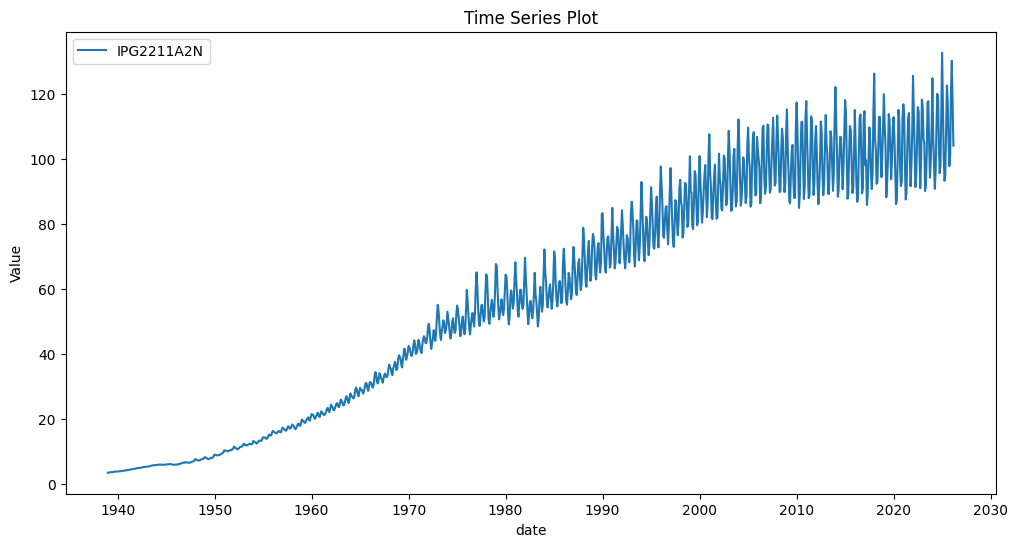

ADF Statistic: -0.513073


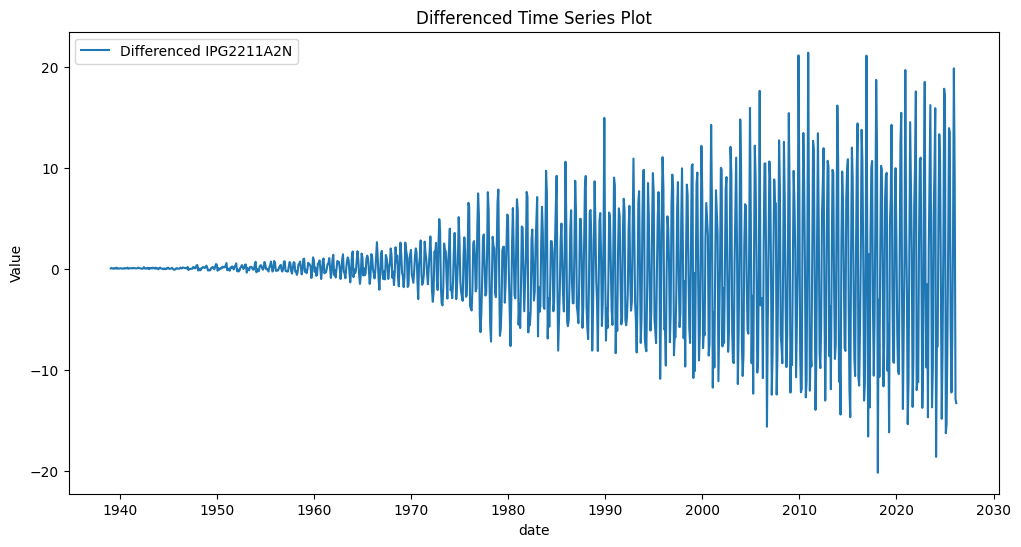

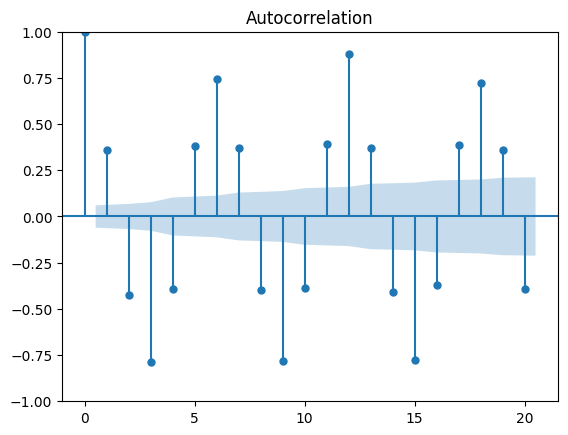

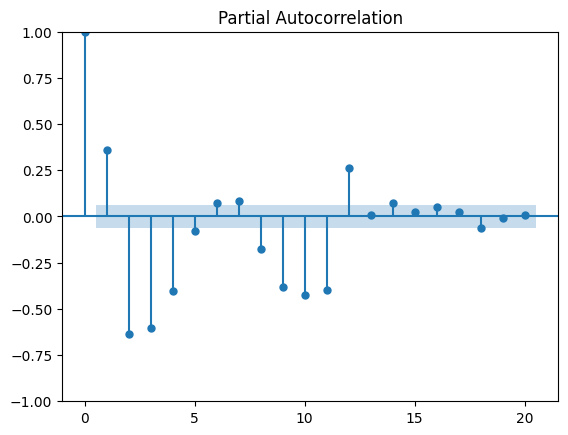

In [12]:
#Zeitreihe auswählen
time_series = df['IPG2211A2N']

#zeitreihe Plotten:
plt.figure(figsize=(12, 6))
plt.plot(time_series, label='IPG2211A2N')
plt.xlabel('date')
plt.ylabel('Value')
plt.title('Time Series Plot')
plt.legend()
plt.show()

#Stationärität prüfen 
result = adfuller(time_series)
print('ADF Statistic: %f' % result[0])

#Differenzieren der zeitreihe und plotten
time_series_diff = time_series.diff().dropna()
plt.figure(figsize=(12, 6))
plt.plot(time_series_diff, label='Differenced IPG2211A2N')
plt.xlabel('date')
plt.ylabel('Value')
plt.title('Differenced Time Series Plot')
plt.legend()
plt.show()

#ACF und PACF Plotten
plot_acf(time_series_diff, lags=20)
plot_pacf(time_series_diff, lags=20)
plt.show()



In [ ]:
#Traings und Testdaten erstellen
train_size = int(len(time_series) * 0.8)    
train, test = time_series[0:train_size], time_series[train_size:]



c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             IPG2211A2N   No. Observations:                  837
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -2170.489
Date:                Sat, 09 May 2026   AIC                           4352.978
Time:                        12:34:15   BIC                           4381.357
Sample:                    01-01-1939   HQIC                          4363.856
                         - 09-01-2008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.0230     66.834      0.704      0.482     -83.970     178.016
ar.L1          1.3771      0.040     34.146      0.000       1.298       1.456
ar.L2         -0.3771      0.040     -9.417      0.000      -0.456      -0.299
ma.L1         -0.2352      0.034     -6.857      0.000      -0.302      -0.168
ma.L2         -0.6307      0.025    -25.098      0.000      -0.680      -0.581
sigma2        10.3866      0.357     29.094      0.000       9.687      11.086
===================================================================================
Ljung-Box (L1) (Q):                   7.76   Jarque-Bera (JB):               351.73
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):             122.06   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""